# EXAMEN N°1
**Durée :** 2h   

**CONSIGNES :**   
Vous avez un fichier csv dans le dossier, ainsi qu'un fichier geojson des départements de France.       
Le fichier csv contient des informations provenant de l'INSEE sur les créations d'entreprises en France de 2012 à 2024, classées par départements/régions/France entière.    

Vous me produirez deux cartes Choroplèthes :
- Une première représentant les données pour l'année durant laquelle **le nombre d'entreprises créées est le minimum**.
    * Taille de la figure : 12,10
    * Titre obligatoire
    * Légende obligatoire
    * palette : cool
      
- Une seconde pour l'année durant laquelle **le nombre d'entreprises créées est le maximum**.
    * Taille de la figure : 12,10
    * Titre obligatoire
    * Légende obligatoire
    * palette : cool
- Pour les deux cartes, vous représenterez les données **par département**.

**DÉTAILS :**    
- **Vous avez le droit** aux cours
- **Vous avez le droit** d'utiliser internet
- **Vous n'avez pas le droit d'utiliser d'outils d'intelligence artificielle**
- Si vous produisez du code qui ne provient pas de mon cours, vous devrez me l'expliquer avec vos mots dans une cellule à côté ou en commentaire du code
- Si c'est pas expliqué avec vos mots, vous n'aurez pas de points


**CE QUI EST ATTENDU DE VOUS :**
- Lire un csv et un geojson
- Comprendre la structure des données que vous lisez
- Produire une jointure
- Filtrer les données
- Les projeter sur une carte
- L'intégralité de ces éléments ont été vus dans le cours


**RENDU DE VOS EXAMENS :**
- Enregistrez le, puis :
  - Déposez le sur Moodle  

In [3]:
# Import des bibliothèques
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

# Import des deux jeux de données
df = pd.read_csv("data.csv", encoding="utf-8")
gdf = gpd.read_file("departements.geojson")

# visualisation des jeux de données
display(df)
display(gdf)

,GEO_OBJECT,TIME_PERIOD,OBS_VALUE,code
0,DEP,2012,4579,01
1,DEP,2013,4595,01
2,DEP,2014,4916,01
3,DEP,2015,4435,01
4,DEP,2016,4848,01
...,...,...,...,...
1555,FRANCE,2020,900169,F
1556,FRANCE,2021,1050520,F
1557,FRANCE,2022,1061969,F
1558,FRANCE,2023,1051476,F


,code,nom,geometry
0,01,Ain,"POLYGON ((4.78021 46.17668, 4.78024 46.18905, ..."
1,02,Aisne,"POLYGON ((3.17296 50.01131, 3.17382 50.01186, ..."
2,03,Allier,"POLYGON ((3.03207 46.79491, 3.03424 46.7908, 3..."
3,04,Alpes-de-Haute-Provence,"POLYGON ((5.67604 44.19143, 5.67817 44.19051, ..."
4,05,Hautes-Alpes,"POLYGON ((6.26057 45.12685, 6.26417 45.12641, ..."
...,...,...,...
91,91,Essonne,"POLYGON ((2.22656 48.7761, 2.22866 48.77451, 2..."
92,92,Hauts-de-Seine,"POLYGON ((2.29097 48.95097, 2.29162 48.95077, ..."
93,93,Seine-Saint-Denis,"POLYGON ((2.55306 49.00982, 2.55814 49.01201, ..."
94,94,Val-de-Marne,"POLYGON ((2.3319 48.81701, 2.33371 48.81677, 2..."


In [4]:
# jointure
tot = gdf.merge(df, on="code")
display(tot)

,code,nom,geometry,GEO_OBJECT,TIME_PERIOD,OBS_VALUE
0,01,Ain,"POLYGON ((4.78021 46.17668, 4.78024 46.18905, ...",DEP,2012,4579
1,01,Ain,"POLYGON ((4.78021 46.17668, 4.78024 46.18905, ...",DEP,2013,4595
2,01,Ain,"POLYGON ((4.78021 46.17668, 4.78024 46.18905, ...",DEP,2014,4916
3,01,Ain,"POLYGON ((4.78021 46.17668, 4.78024 46.18905, ...",DEP,2015,4435
4,01,Ain,"POLYGON ((4.78021 46.17668, 4.78024 46.18905, ...",DEP,2016,4848
...,...,...,...,...,...,...
1477,95,Val-d'Oise,"POLYGON ((2.59052 49.07965, 2.59013 49.07786, ...",DEP,2020,21324
1478,95,Val-d'Oise,"POLYGON ((2.59052 49.07965, 2.59013 49.07786, ...",DEP,2021,23874
1479,95,Val-d'Oise,"POLYGON ((2.59052 49.07965, 2.59013 49.07786, ...",DEP,2022,23846
1480,95,Val-d'Oise,"POLYGON ((2.59052 49.07965, 2.59013 49.07786, ...",DEP,2023,23847


In [5]:
# sélection des données portant sur toute la France pour les valeurs min et max
# On filtre sur df vu que tot n'a plus les données pour la France
df_fr = df[df["GEO_OBJECT"]=="FRANCE"]

In [6]:
# On cherche les valeurs max et min
minimum = df_fr.loc[df_fr["OBS_VALUE"].idxmin()]
maximum = df_fr.loc[df_fr["OBS_VALUE"].idxmax()]
display(minimum, maximum)

GEO_OBJECT     FRANCE
TIME_PERIOD      2015
OBS_VALUE      564745
code                F
Name: 1550, dtype: object

GEO_OBJECT      FRANCE
TIME_PERIOD       2024
OBS_VALUE      1111238
code                 F
Name: 1559, dtype: object

In [7]:
# On filtre sur le code DEP
tot = tot[tot["GEO_OBJECT"] == "DEP"]
# On produit le df pour la valeur minimale :
gdf_min = tot[tot["TIME_PERIOD"] == minimum["TIME_PERIOD"]]
#Et pour la valeur max :
gdf_max = tot[tot["TIME_PERIOD"] == maximum["TIME_PERIOD"]]

In [8]:
display(gdf_max)

,code,nom,geometry,GEO_OBJECT,TIME_PERIOD,OBS_VALUE
12,01,Ain,"POLYGON ((4.78021 46.17668, 4.78024 46.18905, ...",DEP,2024,9188
38,02,Aisne,"POLYGON ((3.17296 50.01131, 3.17382 50.01186, ...",DEP,2024,5000
64,03,Allier,"POLYGON ((3.03207 46.79491, 3.03424 46.7908, 3...",DEP,2024,3484
90,04,Alpes-de-Haute-Provence,"POLYGON ((5.67604 44.19143, 5.67817 44.19051, ...",DEP,2024,2486
116,05,Hautes-Alpes,"POLYGON ((6.26057 45.12685, 6.26417 45.12641, ...",DEP,2024,2219
...,...,...,...,...,...,...
1403,91,Essonne,"POLYGON ((2.22656 48.7761, 2.22866 48.77451, 2...",DEP,2024,23662
1416,92,Hauts-de-Seine,"POLYGON ((2.29097 48.95097, 2.29162 48.95077, ...",DEP,2024,37236
1429,93,Seine-Saint-Denis,"POLYGON ((2.55306 49.00982, 2.55814 49.01201, ...",DEP,2024,43449
1455,94,Val-de-Marne,"POLYGON ((2.3319 48.81701, 2.33371 48.81677, 2...",DEP,2024,31143


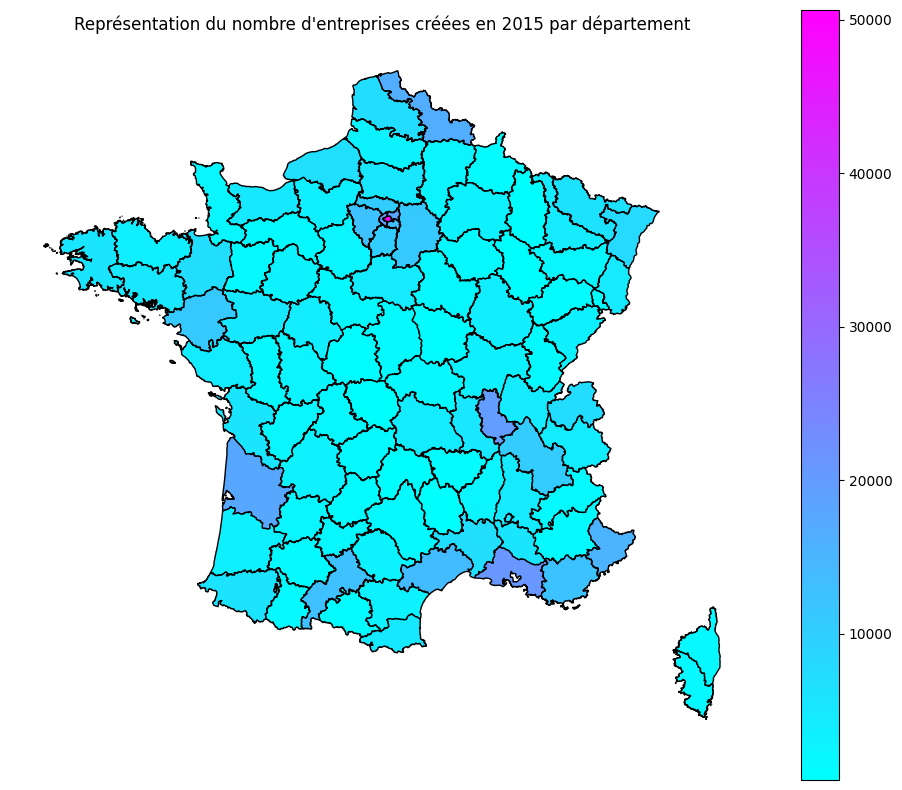

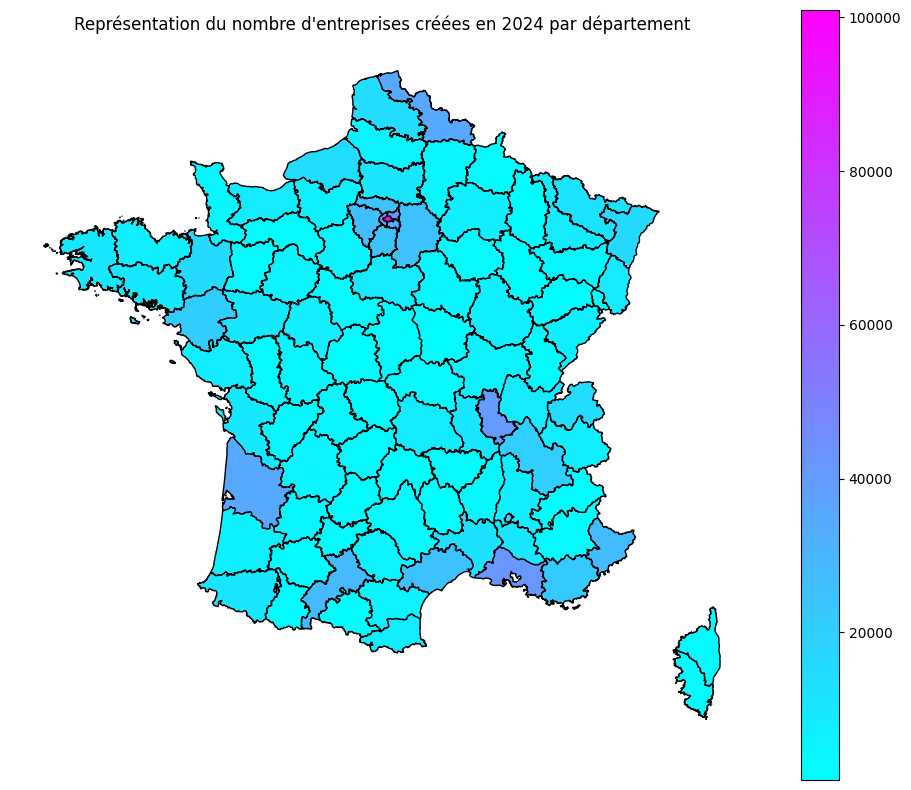

In [9]:
# On projette sur deux cartes
#Minimum :
fig,ax=plt.subplots(1,1,figsize=(12,10))
gdf_min.plot(
    ax=ax,
    column="OBS_VALUE",
    cmap="cool",
    legend=True,
    edgecolor="black"
)
plt.axis("off")
plt.title("Représentation du nombre d'entreprises créées en 2015 par département")
plt.show()

#Maximum :

fig_2,ax_2=plt.subplots(1,1,figsize=(12,10))
gdf_max.plot(
    ax=ax_2,
    column="OBS_VALUE",
    cmap="cool",
    legend=True,
    edgecolor="black"
)
plt.axis("off")
plt.title("Représentation du nombre d'entreprises créées en 2024 par département")
plt.show()

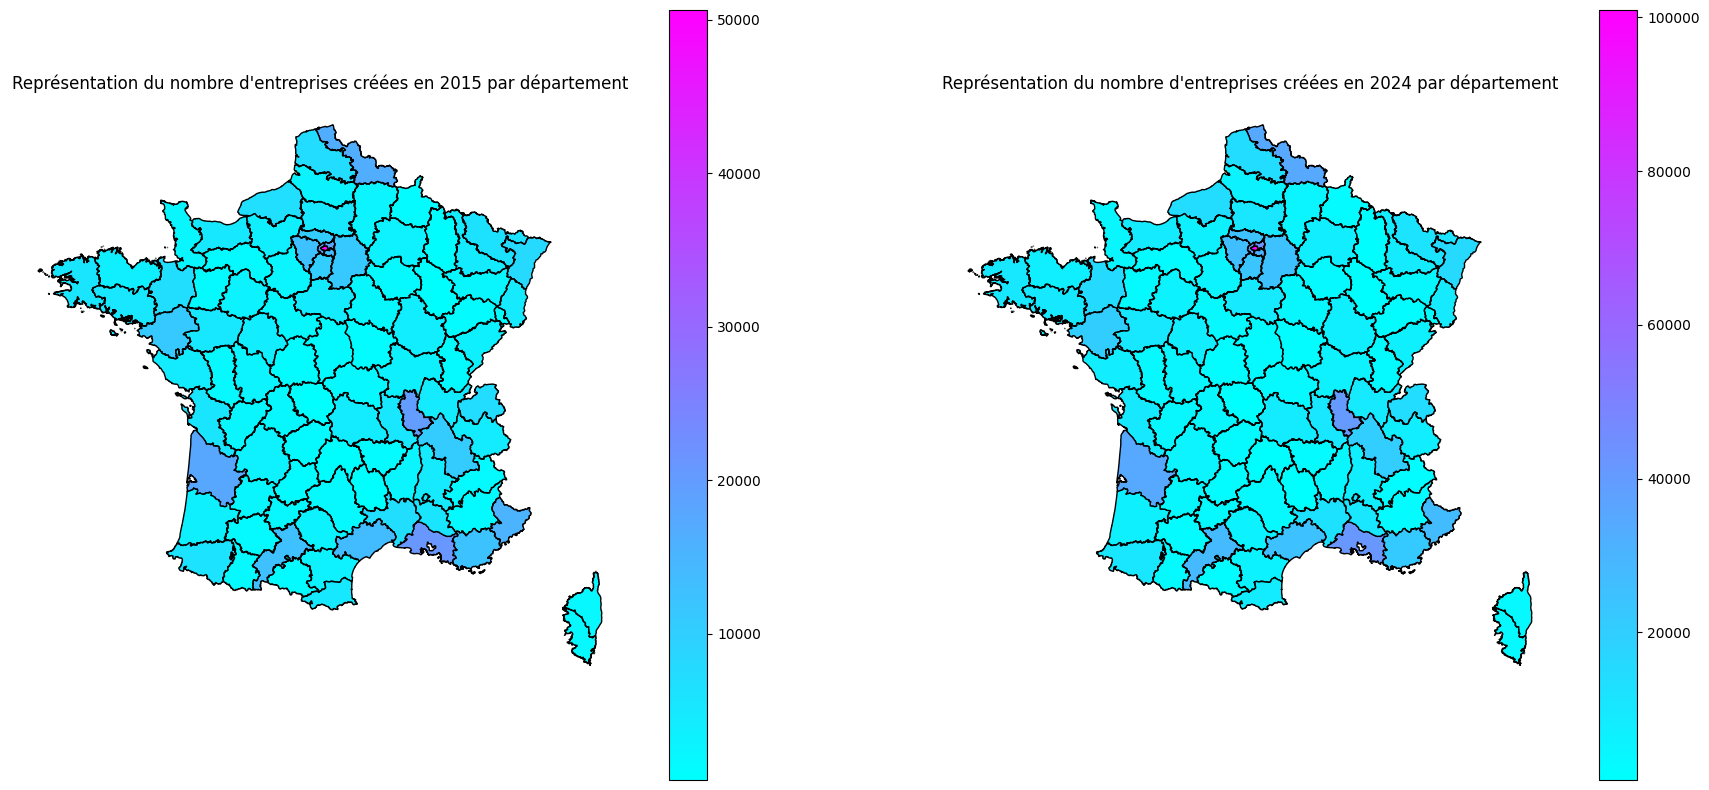

In [10]:
# Bonus :
# Mettez vos deux cartes sur une seule figure, en les plaçant côte à côte

fig,ax=plt.subplots(1,2,figsize=(22,10))
gdf_min.plot(
    ax=ax[0],
    column="OBS_VALUE",
    cmap="cool",
    legend=True,
    edgecolor="black"
)
ax[0].axis("off")
ax[0].set_title("Représentation du nombre d'entreprises créées en 2015 par département")

gdf_max.plot(
    ax=ax[1],
    column="OBS_VALUE",
    cmap="cool",
    legend=True,
    edgecolor="black"
)
ax[1].axis("off")
ax[1].set_title("Représentation du nombre d'entreprises créées en 2024 par département")
plt.show()

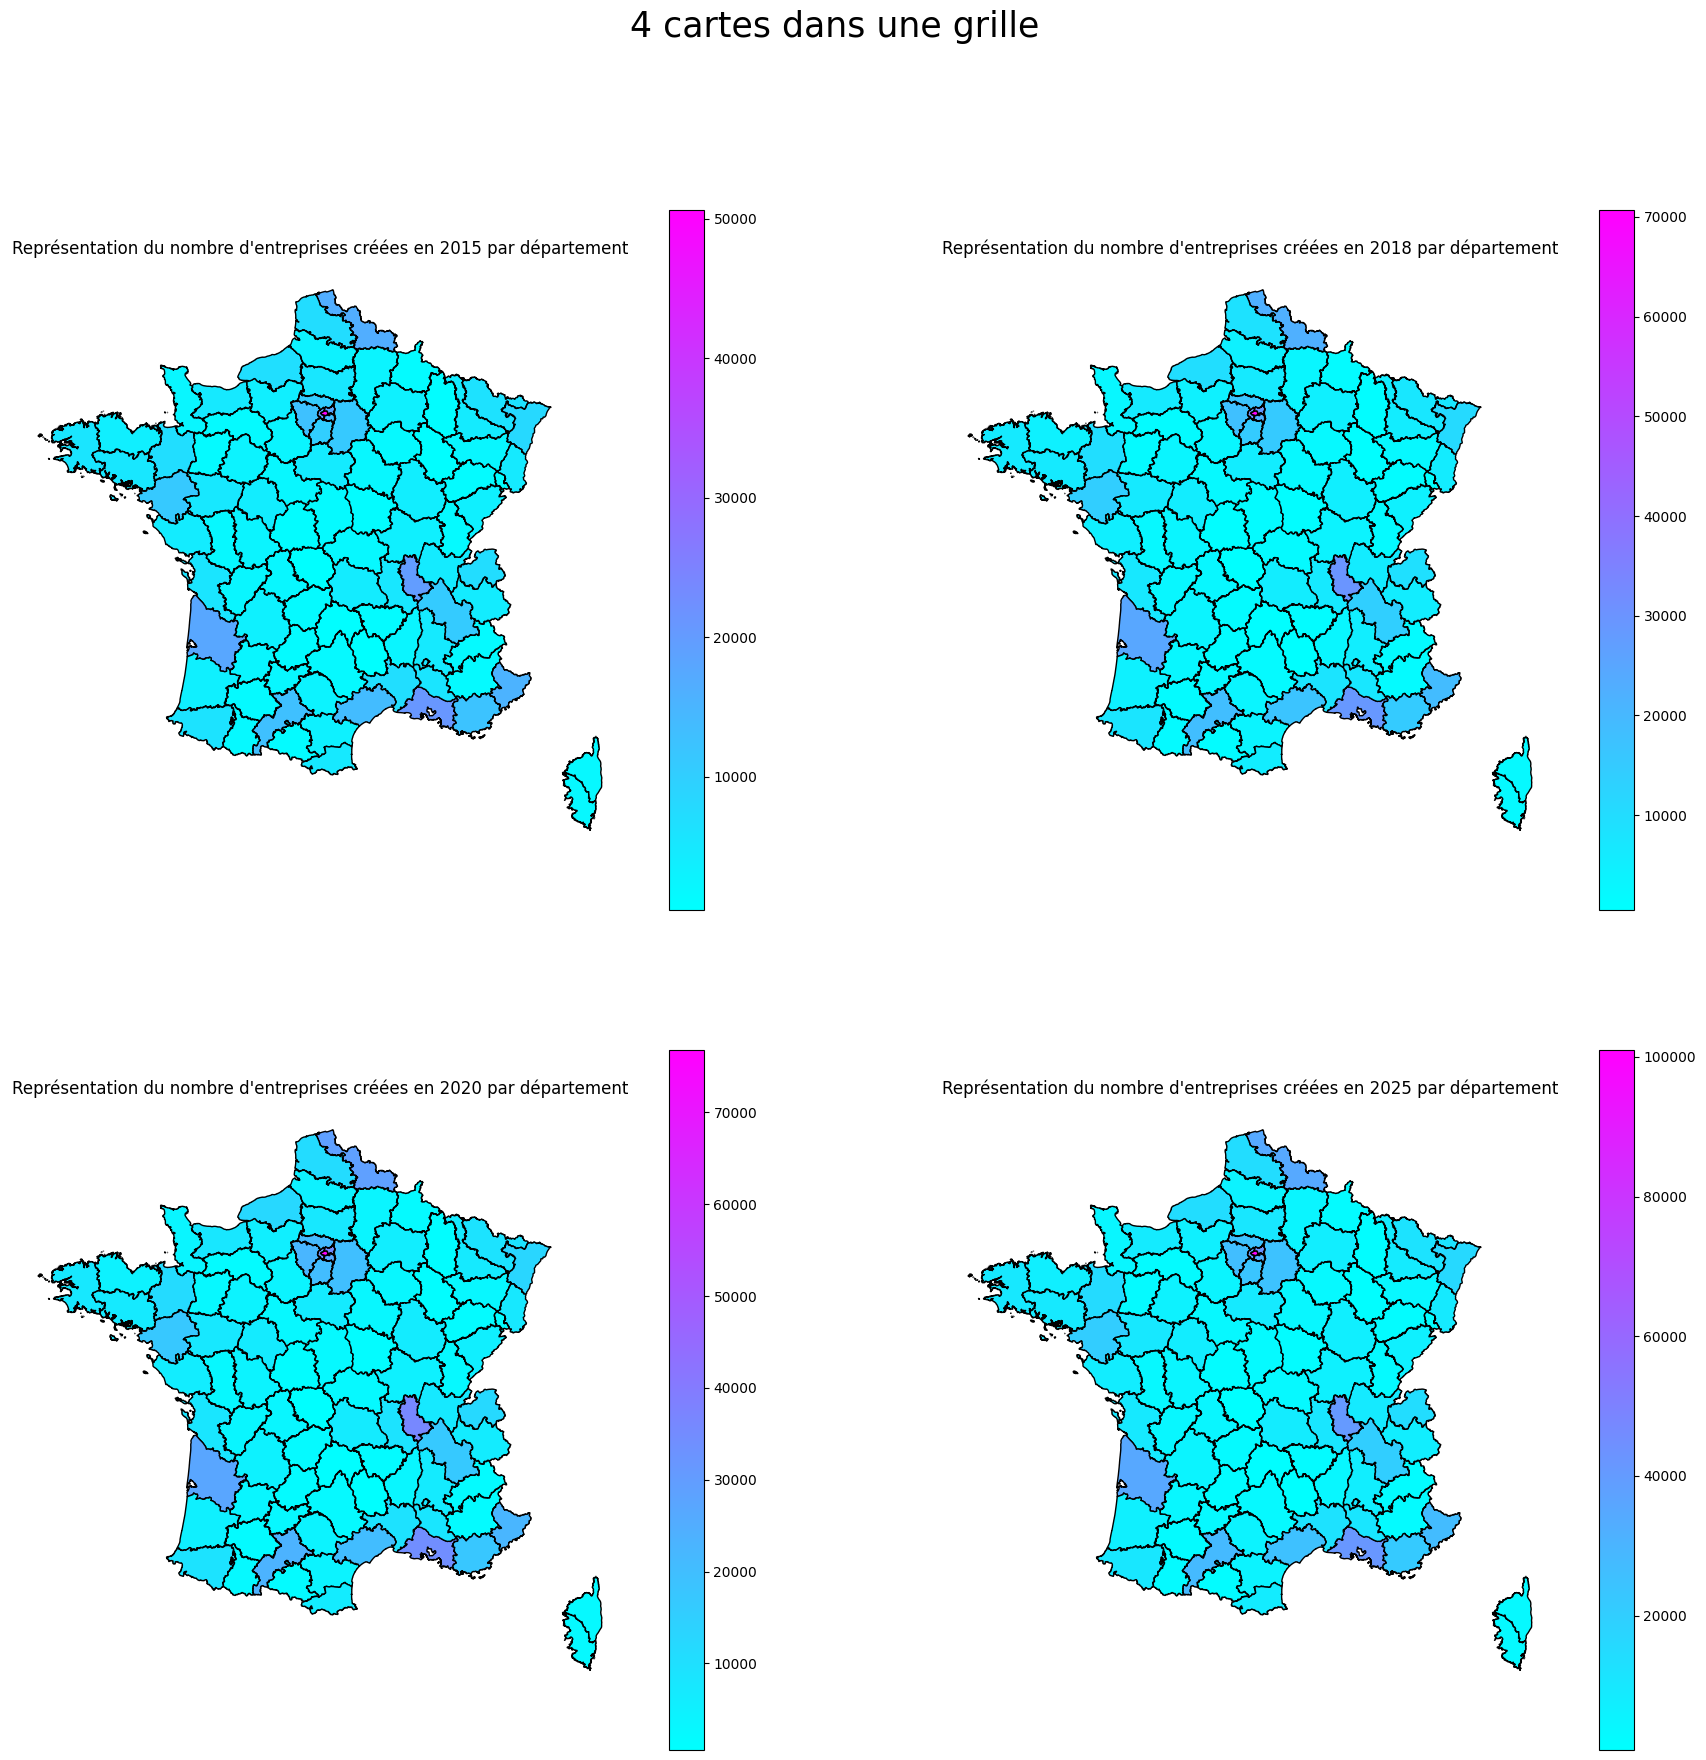

In [17]:
# Bonus 2 :
# plottez deux autres années de votre choix, réalisez un carré de 2*2 cartes et commentez pourquoi cette représentation pose problème.
# Indice : axe[x][y] avec x = position dans la ligne et y = position dans la colonne

# On produit le df pour une année quelconque :
gdf_2018 = tot[tot["TIME_PERIOD"] == 2018]
#Et pour l'autre :
gdf_2020 = tot[tot["TIME_PERIOD"] == 2020]

fig,ax=plt.subplots(2,2,figsize=(22,20))
gdf_min.plot(
    ax=ax[0][0],
    column="OBS_VALUE",
    cmap="cool",
    legend=True,
    edgecolor="black"
)
ax[0][0].axis("off")
ax[0][0].set_title("Représentation du nombre d'entreprises créées en 2015 par département")

gdf_2018.plot(
    ax=ax[0][1],
    column="OBS_VALUE",
    cmap="cool",
    legend=True,
    edgecolor="black"
)
ax[0][1].axis("off")
ax[0][1].set_title("Représentation du nombre d'entreprises créées en 2018 par département")

gdf_2020.plot(
    ax=ax[1][0],
    column="OBS_VALUE",
    cmap="cool",
    legend=True,
    edgecolor="black"
)
ax[1][0].axis("off")
ax[1][0].set_title("Représentation du nombre d'entreprises créées en 2020 par département")

gdf_max.plot(
    ax=ax[1][1],
    column="OBS_VALUE",
    cmap="cool",
    legend=True,
    edgecolor="black"
)
ax[1][1].axis("off")
ax[1][1].set_title("Représentation du nombre d'entreprises créées en 2025 par département")

fig.suptitle("4 cartes dans une grille", fontsize=25)
plt.show()